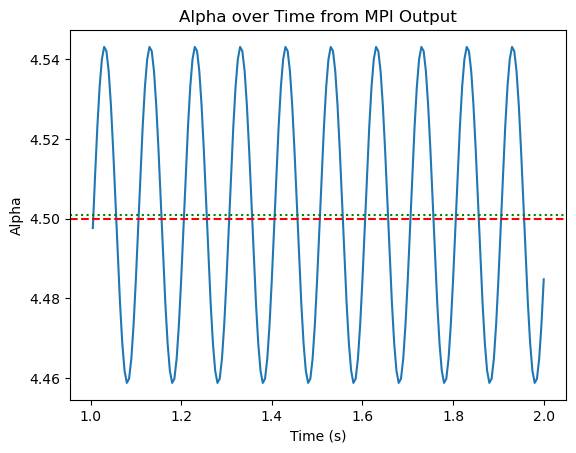

amplitude, period: (np.float64(0.010000000000000004), np.float64(0.10000000000000002))


In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from solver import get_homogeneous_solution

def get_params_from_index(index, amplitudes, periods):
    n_amp = len(amplitudes)
    n_period = len(periods)
    i = index // n_period
    j = index % n_period
    return amplitudes[i], periods[j]

def get_range(x_min, x_max, n_x):
    return np.exp(np.linspace(np.log(x_min), np.log(x_max), n_x))

amplitudes = get_range(0.01, 0.5, 4)
periods = get_range(0.1, 10.0, 8)

index = 0

filename = f"timeseries/mpi_output_index{index}.txt"
data = np.loadtxt(filename, delimiter=";")
times = data[:,0]
alphas = data[:,1]
plt.plot(times, alphas)
plt.axhline(10*(1-get_homogeneous_solution(0, [10.0, 10.0, 0.1])), color='red', linestyle='--', label='Homogeneous Solution')
plt.axhline(np.mean(alphas), color='green', linestyle=':', label='Mean Alpha')
plt.xlabel("Time (s)")
plt.ylabel("Alpha")
plt.title("Alpha over Time from MPI Output")
plt.show()

print("amplitude, period:", get_params_from_index(index, amplitudes, periods))


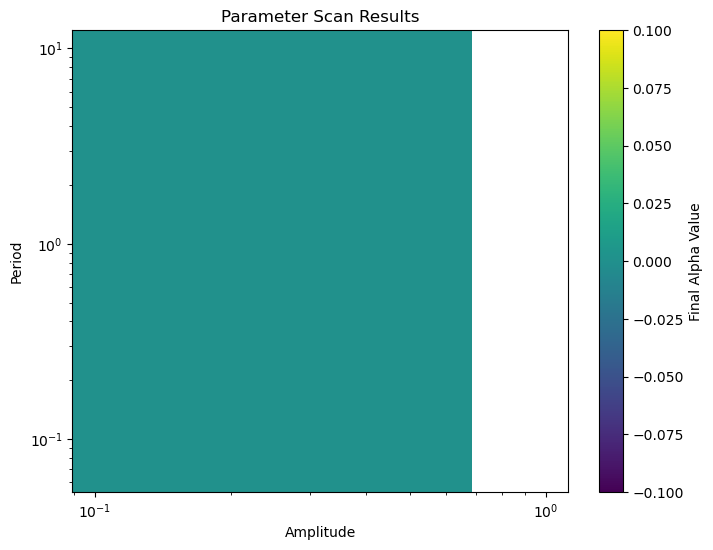

In [23]:
import numpy as np 
import matplotlib.pyplot as plt

results = np.loadtxt("results.txt", delimiter=";", skiprows=1)

def get_range(x_min, x_max, n_x):
    return np.exp(np.linspace(np.log(x_min), np.log(x_max), n_x))

amplitudes = get_range(0.01, 0.5, 4)
periods = get_range(0.1, 10.0, 8)

# make a colormap of results with amplitudes on x-axis and periods on y-axis
plt.figure(figsize=(8, 6))
cmap = plt.pcolor(amplitudes, periods, results.T, shading='auto', cmap='viridis', vmin=-0.1, vmax=0.1)
plt.colorbar(cmap, label='Final Alpha Value')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Amplitude')
plt.ylabel('Period')
plt.title('Parameter Scan Results')
plt.show()